<a href="https://colab.research.google.com/github/leozin-sf/cnn-project/blob/main/projeto3_cnn_chestxray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto 3 — Aprendizado Profundo: CNNs
## Classificação Multi-Label de Radiografias de Tórax
### Dataset: NIH Chest X-ray 14 | Transfer Learning com DenseNet121

---
**T326 — Ciência dos Dados** | Professor: Caio Ponte | Turma: 16/17

## 1. Introdução e Objetivo

### Dataset: NIH Chest X-ray 14

O **NIH Chest X-ray 14** é um dos maiores conjuntos de dados públicos de radiografias de tórax do mundo, publicado pelo *National Institutes of Health* (NIH) dos Estados Unidos em 2017. Ele contém:

- **112.120 imagens** de raio-X de tórax em escala de cinza (PNG, ~1024×1024 px)
- **30.805 pacientes** únicos
- **14 condições patológicas** anotadas com rótulos gerados automaticamente via processamento de linguagem natural a partir de laudos médicos

| Condição | Condição | Condição | Condição |
|----------|----------|----------|----------|
| Atelectasis | Cardiomegaly | Consolidation | Edema |
| Effusion | Emphysema | Fibrosis | Hernia |
| Infiltration | Mass | Nodule | Pleural Thickening |
| Pneumonia | Pneumothorax | | |

### Problema: Classificação Multi-Label

Diferente de uma classificação multi-classe (uma única categoria por imagem), este é um problema de **classificação multi-label**: cada radiografia pode apresentar **múltiplas condições simultaneamente** ou nenhuma ("No Finding").

Exemplos reais:
- Uma imagem pode ter *Atelectasis + Effusion* ao mesmo tempo
- Aproximadamente **54% das imagens** são classificadas como "No Finding"
- Condições raras como *Hernia* aparecem em menos de 0,2% das imagens

### Relevância Clínica e Conexão com Sistema em Produção

A detecção automática de condições em raio-X de tórax é uma das áreas mais impactantes da IA médica. Um radiologista analisa em média 80-100 exames por dia, e erros de diagnóstico afetam diretamente o tratamento do paciente.

> **Contexto do projeto:** Este notebook demonstra o processo de treinamento do modelo CNN utilizado no sistema **medc-back** — uma aplicação de saúde em produção que conecta médicos a análises automatizadas de raio-X. O sistema classifica 19 condições usando um modelo Keras pré-treinado (`2409_2004i.h5`) e serve via API REST com Flask.

---
## Configuração do Ambiente

In [1]:
# Dependencias instaladas localmente
# CPU:  python -m pip install -r requirements-cpu.txt
# AMD:  bash scripts/setup_rocm_wsl.sh


In [2]:
import os
os.environ.setdefault('HSA_ENABLE_DXG_DETECTION', '1')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from glob import glob
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print(f'TensorFlow: {tf.__version__}')
GPUS = tf.config.list_physical_devices("GPU")
print(f'GPUs disponíveis: {GPUS}')
if not GPUS:
    raise RuntimeError(
        'GPU AMD nao detectada. O treinamento foi interrompido para evitar '
        'uso acidental da CPU. Reinicie o WSL e valide /dev/dxg e rocminfo.'
    )

for gpu in GPUS:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f'Politica numerica: {mixed_precision.global_policy().name}')
print(f'Seed fixada para reprodutibilidade')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-10 14:53:34.547481: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0-dev0+selfbuilt
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Politica numerica: mixed_float16
Seed fixada para reprodutibilidade


In [3]:
# Configuracao local da API do Kaggle
from pathlib import Path
import sys

kaggle_config = Path.home() / '.kaggle' / 'kaggle.json'
KAGGLE_BIN = Path(sys.executable).with_name('kaggle')

if not kaggle_config.exists():
    raise FileNotFoundError(
        f'Credencial nao encontrada em {kaggle_config}. '
        'Copie o kaggle.json para ~/.kaggle/kaggle.json.'
    )
if not KAGGLE_BIN.exists():
    raise FileNotFoundError(
        'Kaggle CLI nao encontrado na venv. Execute: '
        'python -m pip install -r requirements.txt'
    )

print(f'Kaggle API configurada: {kaggle_config}')
print(f'Kaggle CLI: {KAGGLE_BIN}')


Kaggle API configurada: /home/leozin/.kaggle/kaggle.json
Kaggle CLI: /home/leozin/unifor/ciencia-dados/cnn-project/.venv/bin/kaggle


In [4]:
!{KAGGLE_BIN} datasets files nih-chest-xrays/data

Next Page Token = CfDJ8G82xNY93phHtA6xMwIf8xPmRZK-CSCoUlCBvT3OLHHoHzWvxgdUAHpCzHleiE6qgk4EECFohln8ZSsfSOmfCttyPVe0eu6MqUlzDkotTOVUxBLHxbeNbLT1_llC6wHCbRXbjX_UI3v0HOyCP08OFndDsIPU
name                                   size  creationDate                
----------------------------------  -------  --------------------------  
ARXIV_V5_CHESTXRAY.pdf              8963138  2019-09-24 23:56:19.481000  
BBox_List_2017.csv                    92416  2019-09-24 23:56:19.362000  
Data_Entry_2017.csv                 7861152  2019-09-24 23:56:19.543000  
FAQ_CHESTXRAY.pdf                     72223  2019-09-24 23:56:19.721000  
LOG_CHESTXRAY.pdf                      3919  2019-09-24 23:56:19.430000  
README_CHESTXRAY.pdf                 847223  2019-09-24 23:56:19.407000  
images_001/images/00000001_000.png   457171  2018-02-21 23:57:46.601000  
images_001/images/00000001_001.png   444655  2018-02-21 23:56:51.890000  
images_001/images/00000001_002.png   351772  2018-02-21 23:58:27.109000  
images_

In [5]:
# Download e extracao do Dataset NIH Chest X-ray 14
# ATENCAO: download de aproximadamente 42 GB.

import subprocess
import zipfile

DATA_DIR = Path('data/nih_chestxray').resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

def kaggle_download(*args):
    subprocess.run([str(KAGGLE_BIN), 'datasets', 'download', *args], check=True)

def extract_zip(archive):
    archive = Path(archive)
    if not archive.exists():
        return
    print(f'Extraindo {archive.name}...')
    with zipfile.ZipFile(archive) as zip_file:
        zip_file.extractall(DATA_DIR)

# Metadados e listas oficiais
csv_path = DATA_DIR / 'Data_Entry_2017.csv'
if not csv_path.exists():
    csv_zip = DATA_DIR / 'Data_Entry_2017.csv.zip'
    if not csv_zip.exists():
        kaggle_download('-d', 'nih-chest-xrays/data', '-f',
                        'Data_Entry_2017.csv', '-p', str(DATA_DIR))
    extract_zip(csv_zip)

train_list = DATA_DIR / 'train_val_list.txt'
if not train_list.exists():
    train_zip = DATA_DIR / 'train_val_list.txt.zip'
    if not train_zip.exists():
        kaggle_download('-d', 'nih-chest-xrays/data', '-f',
                        'train_val_list.txt', '-p', str(DATA_DIR))
    extract_zip(train_zip)

test_list_path = DATA_DIR / 'test_list.txt'
if not test_list_path.exists():
    kaggle_download('-d', 'nih-chest-xrays/data', '-f',
                    'test_list.txt', '-p', str(DATA_DIR))

# Imagens completas
all_images = list(DATA_DIR.glob('**/*.png'))
if not all_images:
    data_zip = DATA_DIR / 'data.zip'
    if not data_zip.exists():
        print('Baixando dataset completo (~42 GB)...')
        kaggle_download('-d', 'nih-chest-xrays/data', '-p', str(DATA_DIR))
    extract_zip(data_zip)
    all_images = list(DATA_DIR.glob('**/*.png'))

if not all_images:
    raise RuntimeError('Nenhuma imagem foi encontrada depois da extracao.')

all_images = [str(path) for path in all_images]
print(f'Total de imagens disponiveis: {len(all_images):,}')


Total de imagens disponiveis: 112,120


In [6]:
# Remover o ZIP principal somente depois de confirmar a extracao completa
from pathlib import Path

DATA_DIR = Path('data/nih_chestxray').resolve()
archive_path = DATA_DIR / 'data.zip'
extracted_images = list(DATA_DIR.glob('**/*.png'))
EXPECTED_IMAGES = 112_120

if len(extracted_images) < EXPECTED_IMAGES:
    print(
        f'ZIP preservado: foram encontradas {len(extracted_images):,} de '
        f'{EXPECTED_IMAGES:,} imagens esperadas.'
    )
elif archive_path.exists():
    archive_path.unlink()
    print(f'Extracao confirmada. ZIP removido: {archive_path}')
else:
    print('Extracao confirmada e data.zip ja nao existe.')


Extracao confirmada e data.zip ja nao existe.


In [7]:
extracted = sorted(
    path.name for path in DATA_DIR.iterdir()
    if path.is_dir() and path.name.startswith('images_')
)
print('Pastas de imagens disponiveis:', extracted)


Pastas de imagens disponiveis: ['images_001', 'images_002', 'images_003', 'images_004', 'images_005', 'images_006', 'images_007', 'images_008', 'images_009', 'images_010', 'images_011', 'images_012']


In [8]:
all_images = [str(path) for path in DATA_DIR.glob('**/*.png')]
print(f'Total de imagens disponiveis: {len(all_images):,}')


Total de imagens disponiveis: 112,120


---
## 2. Processamento de Dados

### Estratégia de pré-processamento

Radiografias de tórax apresentam características distintas de fotos naturais:
- Imagens em **escala de cinza** convertidas para RGB (3 canais) para compatibilidade com arquiteturas pré-treinadas
- **Normalização *samplewise***: cada imagem é centralizada (média 0) e normalizada (desvio padrão 1) individualmente — a mesma técnica usada no sistema de produção medc-back
- **Redimensionamento** para 224×224 px (padrão do DenseNet121)
- **Data Augmentation** no conjunto de treino para reduzir overfitting

In [9]:
# Carregamento e analise exploratoria
from pathlib import Path
from zipfile import ZipFile
import pandas as pd

DATA_DIR = Path('data/nih_chestxray').resolve()
CSV_PATH = DATA_DIR / 'Data_Entry_2017.csv'
CSV_ZIP_PATH = DATA_DIR / 'Data_Entry_2017.csv.zip'

if not CSV_PATH.exists() and CSV_ZIP_PATH.exists():
    print(f'Extraindo {CSV_ZIP_PATH.name}...')
    with ZipFile(CSV_ZIP_PATH) as zip_file:
        zip_file.extractall(DATA_DIR)

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f'Arquivo nao encontrado: {CSV_PATH}. '
        'Execute primeiro a celula de download e extracao do dataset.'
    )

all_images = [str(path) for path in DATA_DIR.glob('**/*.png')]
df = pd.read_csv(CSV_PATH)

print('Shape do DataFrame:', df.shape)
print(f'Imagens encontradas: {len(all_images):,}')
print('\nColunas:', df.columns.tolist())
df.head()


Shape do DataFrame: (112120, 12)
Imagens encontradas: 112,120

Colunas: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [10]:
# Engenharia de features: binarizacao dos rotulos
from pathlib import Path

CONDITIONS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

# Normalizar nomes no CSV (substituir espaço por underscore)
df['Finding Labels'] = df['Finding Labels'].str.replace(' ', '_')

# Criar coluna binária para cada condição (multi-label → one-hot por classe)
for cond in CONDITIONS:
    df[cond] = df['Finding Labels'].str.contains(cond).astype(int)

# Criar mapa de imagem → caminho completo (apenas imagens baixadas)
image_map = {Path(p).name: str(p) for p in all_images}

# Filtrar apenas imagens que foram baixadas
df = df[df['Image Index'].isin(image_map.keys())].copy()
df['filepath'] = df['Image Index'].map(image_map)
df['n_conditions'] = df[CONDITIONS].sum(axis=1)

print(f'Imagens disponíveis para treinamento: {len(df):,}')
print(f'\nDistribuição de "No Finding": {(df["Finding Labels"] == "No_Finding").mean()*100:.1f}%')
print('\nRótulos por condição (primeiras 5):')
print(df[CONDITIONS].sum().sort_values(ascending=False).head())

Imagens disponíveis para treinamento: 112,120

Distribuição de "No Finding": 53.8%

Rótulos por condição (primeiras 5):
Infiltration    19894
Effusion        13317
Atelectasis     11559
Nodule           6331
Mass             5782
dtype: int64


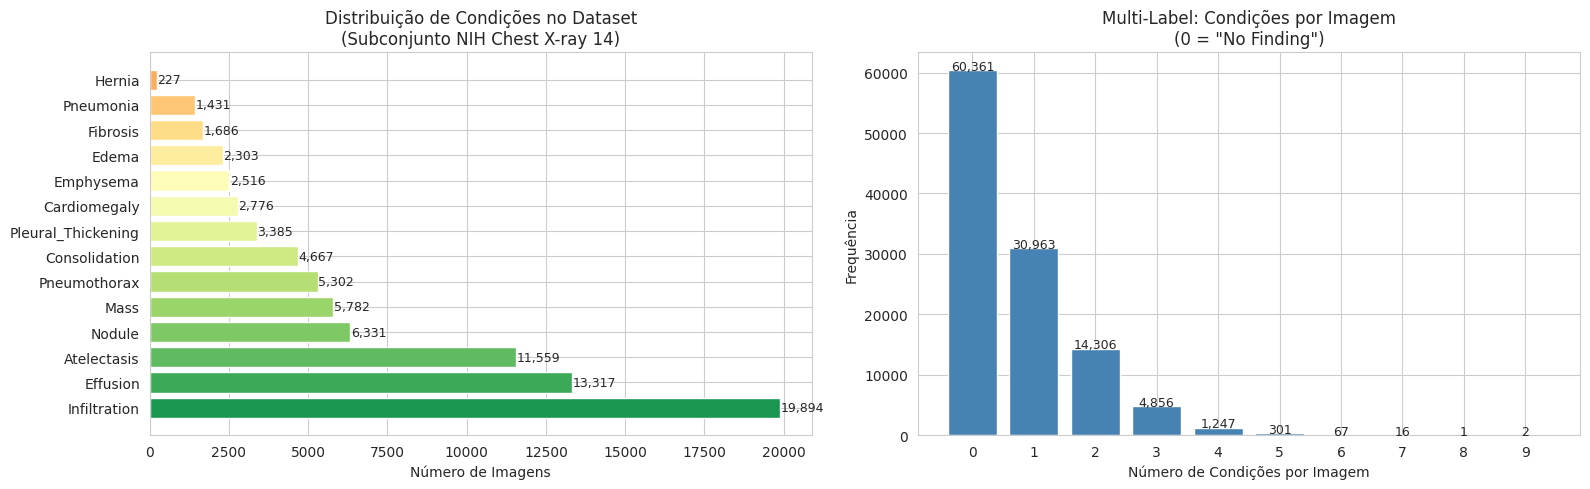


Desbalanceamento: 88x entre Infiltration e Hernia


In [11]:
# Analise exploratoria: distribuicao de classes
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Contagem por condição
counts = df[CONDITIONS].sum().sort_values(ascending=False)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(CONDITIONS)))
axes[0].barh(counts.index, counts.values, color=colors[::-1])
axes[0].set_xlabel('Número de Imagens')
axes[0].set_title('Distribuição de Condições no Dataset\n(Subconjunto NIH Chest X-ray 14)', fontsize=12)
for i, (val, name) in enumerate(zip(counts.values, counts.index)):
    axes[0].text(val + 20, i, f'{val:,}', va='center', fontsize=9)

# Gráfico 2: Número de condições por imagem
df['n_conditions'] = df[CONDITIONS].sum(axis=1)
vc = df['n_conditions'].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Número de Condições por Imagem')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Multi-Label: Condições por Imagem\n(0 = "No Finding")', fontsize=12)
for x, y in zip(range(len(vc)), vc.values):
    axes[1].text(x, y + 50, f'{y:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('distribuicao_classes.png', bbox_inches='tight')
plt.show()
print(f'\nDesbalanceamento: {counts.max()/counts.min():.0f}x entre Infiltration e Hernia')

In [12]:
# Divisao treino / validacao / teste por paciente
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit

SEED = 42
DATA_DIR = Path('data/nih_chestxray').resolve()

test_list_path = DATA_DIR / 'test_list.txt'
if not test_list_path.exists():
    raise FileNotFoundError(f'Lista de teste nao encontrada: {test_list_path}')

with test_list_path.open() as file:
    test_list = set(file.read().splitlines())

# Teste oficial do NIH. A validacao e separada por Patient ID para evitar
# que imagens do mesmo paciente aparecam no treino e na validacao.
df_test = df[df['Image Index'].isin(test_list)].copy()
df_train_val = df[~df['Image Index'].isin(test_list)].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(
    splitter.split(df_train_val, groups=df_train_val['Patient ID'])
)
df_train = df_train_val.iloc[train_idx].copy()
df_val = df_train_val.iloc[val_idx].copy()

assert set(df_train['Patient ID']).isdisjoint(df_val['Patient ID'])

print('Divisao dos dados:')
print(f'  Treino:     {len(df_train):,} imagens ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Validacao:  {len(df_val):,} imagens ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Teste:      {len(df_test):,} imagens ({len(df_test)/len(df)*100:.1f}%)')
print(f'\n  Total disponivel: {len(df):,} imagens')
print('  Pacientes compartilhados entre treino e validacao: 0')


Divisao dos dados:
  Treino:     73,916 imagens (65.9%)
  Validacao:  12,608 imagens (11.2%)
  Teste:      25,596 imagens (22.8%)

  Total disponivel: 112,120 imagens
  Pacientes compartilhados entre treino e validacao: 0


In [13]:
# Pipeline de dados paralelo com tf.data
import numpy as np
import tensorflow as tf

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(filepath, labels):
    image_bytes = tf.io.read_file(filepath)
    image = tf.io.decode_png(image_bytes, channels=3)
    image = tf.image.resize(image, IMG_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    image = tf.image.per_image_standardization(image)
    return image, labels

def make_dataset(df_split, training=False):
    filepaths = df_split['filepath'].astype(str).to_numpy()
    labels = df_split[CONDITIONS].to_numpy(dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if training:
        dataset = dataset.shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training,
    )
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=training)
    return dataset.prefetch(AUTOTUNE)

train_gen = make_dataset(df_train, training=True)
val_gen = make_dataset(df_val)
test_gen = make_dataset(df_test)

print('Datasets criados com tf.data:')
print(f'  Treino:    {len(df_train):,} amostras | batch {BATCH_SIZE}')
print(f'  Validacao: {len(df_val):,} amostras | batch {BATCH_SIZE}')
print(f'  Teste:     {len(df_test):,} amostras | batch {BATCH_SIZE}')


I0000 00:00:1781114026.774918    4732 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13075 MB memory:  -> device: 0, name: AMD Radeon RX 9070 XT, pci bus id: 0000:0a:00.0


Datasets criados com tf.data:
  Treino:    73,916 amostras | batch 64
  Validacao: 12,608 amostras | batch 64
  Teste:     25,596 amostras | batch 64


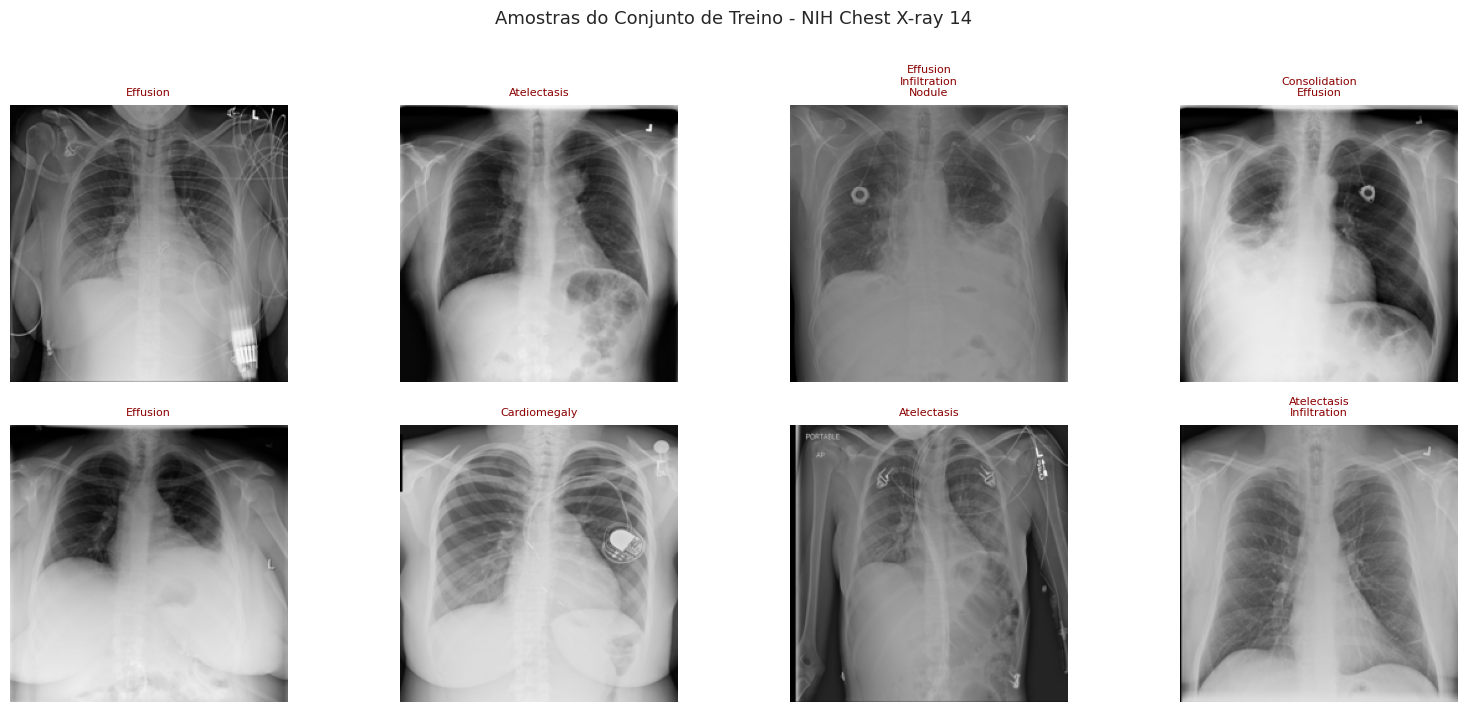

In [14]:
# Visualizacao de amostras
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
sample = df_train[df_train['n_conditions'] > 0].sample(8, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(row['filepath']).convert('RGB').resize((224, 224))
    ax.imshow(img, cmap='gray')
    labels_present = [c for c in CONDITIONS if row[c] == 1]
    ax.set_title('\n'.join(labels_present), fontsize=8, color='darkred')
    ax.axis('off')

plt.suptitle('Amostras do Conjunto de Treino - NIH Chest X-ray 14', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('amostras_treino.png', bbox_inches='tight')
plt.show()


---
## 3. Treinamento e Avaliação

### Arquitetura: Transfer Learning com DenseNet121

**Transfer Learning** consiste em reutilizar o conhecimento de um modelo treinado em um domínio rico (ImageNet — 1,2M imagens, 1.000 classes) como ponto de partida para um domínio específico com menos dados.

**Por que DenseNet121?**
- Cada camada recebe como entrada as saídas de **todas as camadas anteriores** (*dense connections*), o que maximiza o reuso de features e reduz o vanishing gradient
- Referência científica: o artigo **CheXNet** (Rajpurkar et al., 2017) utilizou DenseNet121 para superar radiologistas na detecção de pneumonia usando o mesmo dataset NIH Chest X-ray 14
- A arquitetura DenseNet é a mesma família utilizada no modelo de produção do sistema **medc-back**

### Estratégia de Treinamento em Duas Fases

| Fase | Base Model | Camadas Treináveis | LR |
|------|-----------|-------------------|----|
| 1 — Feature Extraction | Congelado | Apenas o cabeçalho de classificação | 1e-3 |
| 2 — Fine-tuning | Últimas 30 camadas liberadas | Base parcial + cabeçalho | 1e-5 |

### Função de Perda: Weighted Binary Cross-Entropy

Como o dataset é **fortemente desbalanceado** (Hernia < 0,2% vs Infiltration ~18%), usamos pesos adaptativos por classe:

$$\mathcal{L} = -\sum_{i=1}^{14} \left[ w^+_i \cdot y_i \cdot \log(\hat{y}_i) + w^-_i \cdot (1-y_i) \cdot \log(1-\hat{y}_i) \right]$$

onde $w^+_i = N_{neg,i} / N_{total,i}$ e $w^-_i = N_{pos,i} / N_{total,i}$

In [15]:
# ── Cálculo dos Pesos por Classe ──────────────────────────────────────────
pos_counts = df_train[CONDITIONS].sum()  # Positivos por classe
neg_counts = len(df_train) - pos_counts  # Negativos por classe
total      = len(df_train)

# Pesos: classes raras recebem maior penalidade quando erradas
pos_weights = (neg_counts / total).values
neg_weights = (pos_counts / total).values

print('Pesos por classe (pos_weight — penalidade para falsos negativos):')
for cond, pw in zip(CONDITIONS, pos_weights):
    print(f'  {cond:<20} {pw:.4f}')

Pesos por classe (pos_weight — penalidade para falsos negativos):
  Atelectasis          0.9053
  Cardiomegaly         0.9803
  Consolidation        0.9664
  Edema                0.9838
  Effusion             0.8997
  Emphysema            0.9828
  Fibrosis             0.9858
  Hernia               0.9985
  Infiltration         0.8396
  Mass                 0.9533
  Nodule               0.9453
  Pleural_Thickening   0.9747
  Pneumonia            0.9900
  Pneumothorax         0.9691


In [16]:
# Funcao de perda ponderada serializavel
import tensorflow as tf

@tf.keras.utils.register_keras_serializable(package='cnn_project')
class WeightedBinaryCrossentropy(tf.keras.losses.Loss):
    def __init__(self, pos_weights, neg_weights, epsilon=1e-7,
                 name='weighted_binary_crossentropy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.pos_weights = [float(value) for value in pos_weights]
        self.neg_weights = [float(value) for value in neg_weights]
        self.epsilon = float(epsilon)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, self.epsilon, 1 - self.epsilon)
        pos_weights = tf.constant(self.pos_weights, dtype=tf.float32)
        neg_weights = tf.constant(self.neg_weights, dtype=tf.float32)

        loss_pos = -pos_weights * y_true * tf.math.log(y_pred)
        loss_neg = -neg_weights * (1 - y_true) * tf.math.log(1 - y_pred)
        return tf.reduce_sum(loss_pos + loss_neg, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({
            'pos_weights': self.pos_weights,
            'neg_weights': self.neg_weights,
            'epsilon': self.epsilon,
        })
        return config

def weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    return WeightedBinaryCrossentropy(pos_weights, neg_weights, epsilon)

print('Funcao de perda definida: Weighted Binary Cross-Entropy')
print(f'  Numero de classes: {len(CONDITIONS)}')
print('  Ativacao de saida: sigmoid (probabilidade independente por classe)')


Funcao de perda definida: Weighted Binary Cross-Entropy
  Numero de classes: 14
  Ativacao de saida: sigmoid (probabilidade independente por classe)


In [17]:
# Construcao do modelo: DenseNet121 + augmentation na GPU
import tensorflow.keras.backend as K
from tensorflow.keras import Sequential
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    BatchNormalization, Dense, Dropout, GlobalAveragePooling2D, Input,
    RandomFlip, RandomRotation, RandomZoom,
)
from tensorflow.keras.models import Model

data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(10 / 360, fill_mode='constant', fill_value=0),
    RandomZoom(0.1, fill_mode='constant', fill_value=0),
], name='data_augmentation')

def build_model(num_classes=14, freeze_base=True):
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = not freeze_base

    inputs = Input(shape=(*IMG_SIZE, 3), name='image')
    x = data_augmentation(inputs)
    # Mantem BatchNormalization da base em modo de inferencia durante o fine-tuning.
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    # Saida float32 evita perda de precisao numerica com mixed_float16.
    outputs = Dense(
        num_classes, activation='sigmoid', dtype='float32', name='predictions'
    )(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base

model, base_model = build_model(num_classes=len(CONDITIONS), freeze_base=True)

total_params = model.count_params()
trainable_params = sum(K.count_params(weight) for weight in model.trainable_weights)
frozen_params = total_params - trainable_params

print('=' * 50)
print('  Arquitetura: DenseNet121 + Classificador')
print('=' * 50)
print(f'  Parametros totais:     {total_params:>12,}')
print(f'  Treinaveis (Fase 1):   {trainable_params:>12,}')
print(f'  Congelados:            {frozen_params:>12,}')
print(f'  Batch size:            {BATCH_SIZE:>12}')
print(f'  Politica numerica:     {tf.keras.mixed_precision.global_policy().name:>12}')
print('=' * 50)


  Arquitetura: DenseNet121 + Classificador
  Parametros totais:        7,055,950
  Treinaveis (Fase 1):         16,398
  Congelados:               7,039,552
  Batch size:                      64
  Politica numerica:     mixed_float16


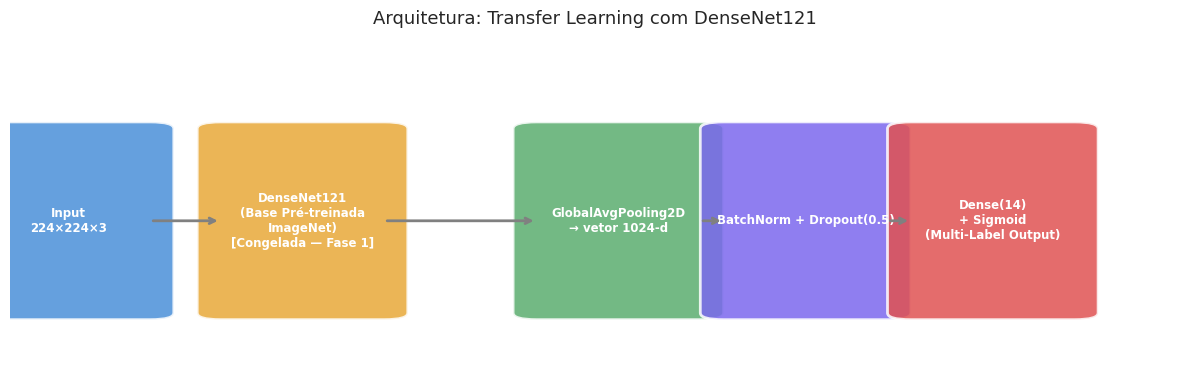

In [18]:
# ── Diagrama da Arquitetura ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

blocks = [
    ('Input\n224×224×3', '#4A90D9', 0.05),
    ('DenseNet121\n(Base Pré-treinada\nImageNet)\n[Congelada — Fase 1]', '#E8A838', 0.25),
    ('GlobalAvgPooling2D\n→ vetor 1024-d', '#5BAD6F', 0.52),
    ('BatchNorm + Dropout(0.5)', '#7B68EE', 0.68),
    ('Dense(14)\n+ Sigmoid\n(Multi-Label Output)', '#E05252', 0.84),
]

for label, color, x in blocks:
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.07, 0.2), 0.14, 0.55,
                                         boxstyle='round,pad=0.02',
                                         facecolor=color, alpha=0.85, edgecolor='white', lw=2))
    ax.text(x, 0.475, label, ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold')

for i in range(len(blocks) - 1):
    x_start = blocks[i][2] + 0.07
    x_end   = blocks[i+1][2] - 0.07
    ax.annotate('', xy=(x_end, 0.475), xytext=(x_start, 0.475),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_title('Arquitetura: Transfer Learning com DenseNet121', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('arquitetura_modelo.png', bbox_inches='tight')
plt.show()


In [19]:
# ── Fase 1: Feature Extraction — Compilação e Treinamento ─────────────────
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 10

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=weighted_loss(pos_weights, neg_weights),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

callbacks_p1 = [
    ModelCheckpoint('best_model_phase1.keras', monitor='val_auc',
                    mode='max', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_auc', mode='max', patience=3,
                  restore_best_weights=True, verbose=1),
]

print(f'Fase 1 — Feature Extraction: treinando cabeçalho por {EPOCHS_PHASE1} épocas...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1,
    verbose=1
)

Fase 1 — Feature Extraction: treinando cabeçalho por 5 épocas...
Epoch 1/5
  57/1154 ━━━━━━━━━━━━━━━━━━━━ 2:13 122ms/step - auc: 0.5221 - loss: 0.9085

2026-06-10 14:54:44.063641: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  72/1154 ━━━━━━━━━━━━━━━━━━━━ 2:12 122ms/step - auc: 0.5298 - loss: 0.8986

2026-06-10 14:54:46.000445: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


1154/1154 ━━━━━━━━━━━━━━━━━━━━ 201s 136ms/step - auc: 0.6728 - loss: 0.7658 - val_auc: 0.7310 - val_loss: 0.7039
Epoch 2/5
 312/1154 ━━━━━━━━━━━━━━━━━━━━ 1:29 106ms/step - auc: 0.7044 - loss: 0.6941

...

1154/1154 ━━━━━━━━━━━━━━━━━━━━ 476s 412ms/step - auc: 0.7291 - loss: 0.7049 - val_auc: 0.7359 - val_loss: 0.6988
Epoch 5/5
 115/1154 ━━━━━━━━━━━━━━━━━━━━ 1:36 93ms/step - auc: 0.7059 - loss: 0.6726

2026-06-10 15:10:22.347049: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


 281/1154 ━━━━━━━━━━━━━━━━━━━━ 1:33 107ms/step - auc: 0.7125 - loss: 0.6708

2026-06-10 15:10:41.694082: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


1154/1154 ━━━━━━━━━━━━━━━━━━━━ 141s 122ms/step - auc: 0.7337 - loss: 0.7012 - val_auc: 0.7436 - val_loss: 0.6938
Restoring model weights from the end of the best epoch: 5.


In [20]:
# ── Fase 2: Fine-tuning — Descongelar últimas camadas da base ─────────────
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
base_model.trainable = True

# Congelar tudo exceto as últimas 30 camadas
for layer in base_model.layers[:-30]:
    layer.trainable = False

fine_tune_params = sum(K.count_params(w) for w in model.trainable_weights)
print(f'Parâmetros treináveis na Fase 2: {fine_tune_params:,}')

# Recompilar com LR menor para não destruir pesos pré-treinados
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=weighted_loss(pos_weights, neg_weights),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

callbacks_p2 = [
    ModelCheckpoint('best_model_final.keras', monitor='val_auc',
                    mode='max', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_auc', mode='max', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1)
]

print(f'\nFase 2 — Fine-tuning: {EPOCHS_PHASE2} épocas com LR = 1e-5...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2,
    verbose=1
)

Parâmetros treináveis na Fase 2: 657,806

Fase 2 — Fine-tuning: 10 épocas com LR = 1e-5...
Epoch 1/10
  68/1154 ━━━━━━━━━━━━━━━━━━━━ 2:02 113ms/step - auc: 0.6915 - loss: 0.6874

2026-06-10 15:12:56.982091: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


 287/1154 ━━━━━━━━━━━━━━━━━━━━ 1:31 105ms/step - auc: 0.7060 - loss: 0.6937

2026-06-10 15:13:19.474933: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


1154/1154 ━━━━━━━━━━━━━━━━━━━━ 162s 126ms/step - auc: 0.7346 - loss: 0.7069 - val_auc: 0.7460 - val_loss: 0.6870 - learning_rate: 1.0000e-05
Epoch 2/10
  55/1154 ━━━━━━━━━━━━━━━━━━━━ 2:07 116ms/step - auc: 0.7189 - loss: 0.6697

...

1154/1154 ━━━━━━━━━━━━━━━━━━━━ 144s 125ms/step - auc: 0.7560 - loss: 0.6824 - val_auc: 0.7600 - val_loss: 0.6685 - learning_rate: 1.0000e-05
Epoch 10/10
  65/1154 ━━━━━━━━━━━━━━━━━━━━ 2:04 115ms/step - auc: 0.7293 - loss: 0.6518

2026-06-10 15:34:49.819227: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


 174/1154 ━━━━━━━━━━━━━━━━━━━━ 1:56 119ms/step - auc: 0.7418 - loss: 0.6547

2026-06-10 15:35:03.065973: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


1154/1154 ━━━━━━━━━━━━━━━━━━━━ 145s 125ms/step - auc: 0.7584 - loss: 0.6795 - val_auc: 0.7613 - val_loss: 0.6673 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.


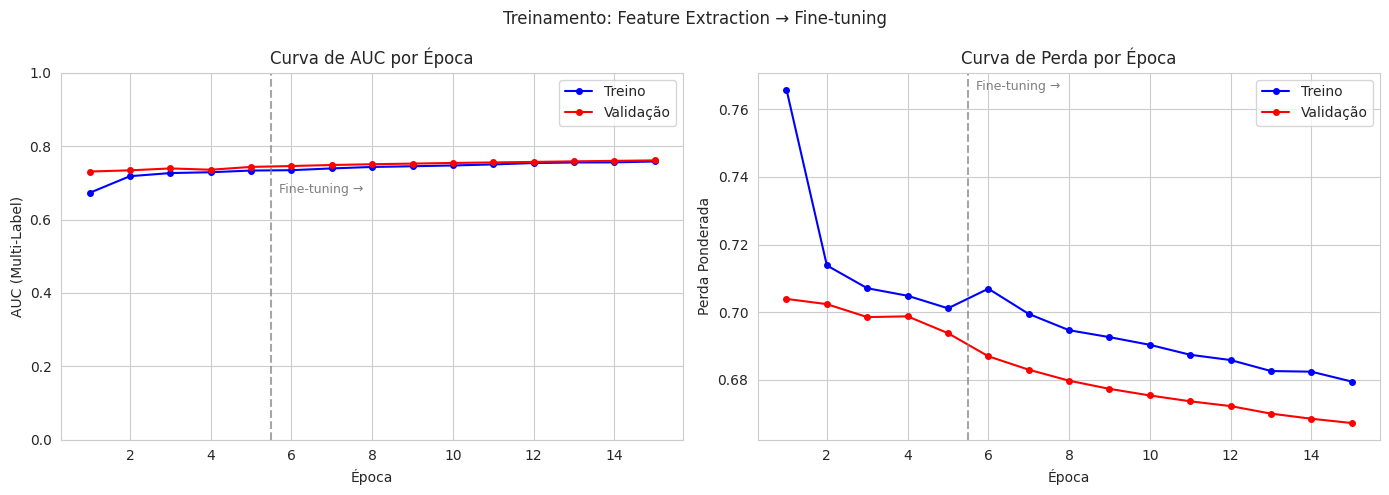

In [21]:
# ── Curvas de Treinamento ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
# Combinar histórico das duas fases
def combine_histories(h1, h2, key):
    return h1.history[key] + h2.history[key]

train_auc  = combine_histories(history1, history2, 'auc')
val_auc    = combine_histories(history1, history2, 'val_auc')
train_loss = combine_histories(history1, history2, 'loss')
val_loss   = combine_histories(history1, history2, 'val_loss')
epochs_ran = range(1, len(train_auc) + 1)
split_ep   = len(history1.history['auc'])  # Época onde começa o fine-tuning

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AUC
ax1.plot(epochs_ran, train_auc, 'b-o', label='Treino', markersize=4)
ax1.plot(epochs_ran, val_auc,   'r-o', label='Validação', markersize=4)
ax1.axvline(x=split_ep + 0.5, color='gray', linestyle='--', alpha=0.7)
ax1.text(split_ep + 0.7, min(train_auc), 'Fine-tuning →', fontsize=9, color='gray')
ax1.set_xlabel('Época')
ax1.set_ylabel('AUC (Multi-Label)')
ax1.set_title('Curva de AUC por Época')
ax1.legend()
ax1.set_ylim([0, 1])

# Loss
ax2.plot(epochs_ran, train_loss, 'b-o', label='Treino', markersize=4)
ax2.plot(epochs_ran, val_loss,   'r-o', label='Validação', markersize=4)
ax2.axvline(x=split_ep + 0.5, color='gray', linestyle='--', alpha=0.7)
ax2.text(split_ep + 0.7, max(train_loss), 'Fine-tuning →', fontsize=9, color='gray')
ax2.set_xlabel('Época')
ax2.set_ylabel('Perda Ponderada')
ax2.set_title('Curva de Perda por Época')
ax2.legend()

plt.suptitle('Treinamento: Feature Extraction → Fine-tuning', fontsize=12)
plt.tight_layout()
plt.savefig('curvas_treinamento.png', bbox_inches='tight')
plt.show()

In [22]:
# ── Avaliação no Conjunto de Teste ────────────────────────────────────────
print('Gerando predições no conjunto de teste...')
y_pred = model.predict(test_gen, verbose=1)

# Rótulos reais (reordenados de acordo com o gerador)
y_true = df_test[CONDITIONS].values[:len(y_pred)]

print(f'\ny_pred shape: {y_pred.shape}')
print(f'y_true shape: {y_true.shape}')
print(f'\nExemplo (primeiras 3 predições):')
for i in range(3):
    conds = [CONDITIONS[j] for j in range(len(CONDITIONS)) if y_pred[i,j] > 0.5]
    print(f'  Imagem {i+1}: {conds if conds else ["No Finding"]}')

Gerando predições no conjunto de teste...
400/400 ━━━━━━━━━━━━━━━━━━━━ 59s 146ms/step

y_pred shape: (25596, 14)
y_true shape: (25596, 14)

Exemplo (primeiras 3 predições):
  Imagem 1: ['Atelectasis', 'Fibrosis', 'Hernia', 'Mass', 'Pleural_Thickening']
  Imagem 2: ['Emphysema', 'Fibrosis', 'Hernia', 'Mass', 'Nodule', 'Pleural_Thickening']
  Imagem 3: ['Atelectasis', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Pleural_Thickening', 'Pneumonia']


  AUC MÉDIA (Mean AUC): 0.7288
          Condição  AUC-ROC  Positivos no Teste
            Hernia 0.892552                  86
             Edema 0.786280                 925
      Pneumothorax 0.781049                2665
         Emphysema 0.775747                1093
          Fibrosis 0.769382                 435
      Cardiomegaly 0.754220                1069
          Effusion 0.747854                4658
Pleural_Thickening 0.698185                1143
       Atelectasis 0.685271                3279
            Nodule 0.678711                1623
     Consolidation 0.676552                1815
              Mass 0.670139                1748
      Infiltration 0.669701                6112
         Pneumonia 0.617377                 555


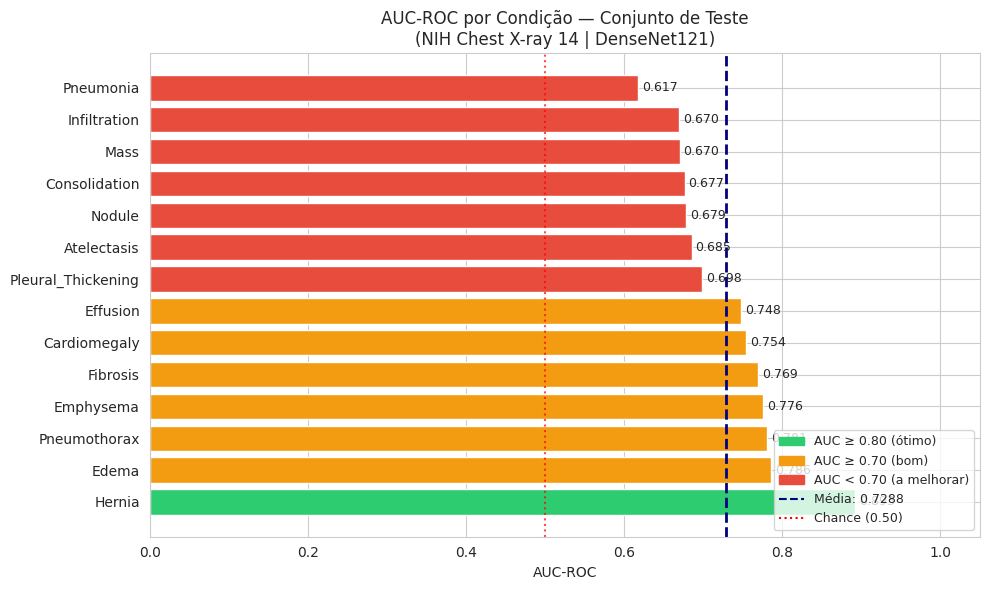

In [23]:
# ── AUC por Classe e Média ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
auc_scores = {}
for i, cond in enumerate(CONDITIONS):
    if y_true[:, i].sum() > 0:  # Ignorar classes sem positivos no teste
        auc_scores[cond] = roc_auc_score(y_true[:, i], y_pred[:, i])

mean_auc = np.mean(list(auc_scores.values()))

# Tabela de resultados
auc_df = pd.DataFrame({
    'Condição': list(auc_scores.keys()),
    'AUC-ROC': list(auc_scores.values()),
    'Positivos no Teste': [int(y_true[:, CONDITIONS.index(c)].sum()) for c in auc_scores.keys()]
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print('=' * 50)
print(f'  AUC MÉDIA (Mean AUC): {mean_auc:.4f}')
print('=' * 50)
print(auc_df.to_string(index=False))

# Gráfico de barras de AUC por classe
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v >= 0.8 else '#f39c12' if v >= 0.7 else '#e74c3c'
          for v in auc_df['AUC-ROC']]
bars = ax.barh(auc_df['Condição'], auc_df['AUC-ROC'], color=colors, edgecolor='white')
ax.axvline(x=mean_auc, color='navy', linestyle='--', lw=2, label=f'Média: {mean_auc:.4f}')
ax.axvline(x=0.5, color='red', linestyle=':', lw=1.5, label='Chance (0.50)', alpha=0.7)
ax.set_xlim([0, 1.05])
ax.set_xlabel('AUC-ROC')
ax.set_title('AUC-ROC por Condição — Conjunto de Teste\n(NIH Chest X-ray 14 | DenseNet121)', fontsize=12)
for bar, val in zip(bars, auc_df['AUC-ROC']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

patches = [
    mpatches.Patch(color='#2ecc71', label='AUC ≥ 0.80 (ótimo)'),
    mpatches.Patch(color='#f39c12', label='AUC ≥ 0.70 (bom)'),
    mpatches.Patch(color='#e74c3c', label='AUC < 0.70 (a melhorar)'),
]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='navy', ls='--', label=f'Média: {mean_auc:.4f}'),
                               plt.Line2D([0],[0], color='red',  ls=':', label='Chance (0.50)')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('auc_por_classe.png', bbox_inches='tight')
plt.show()

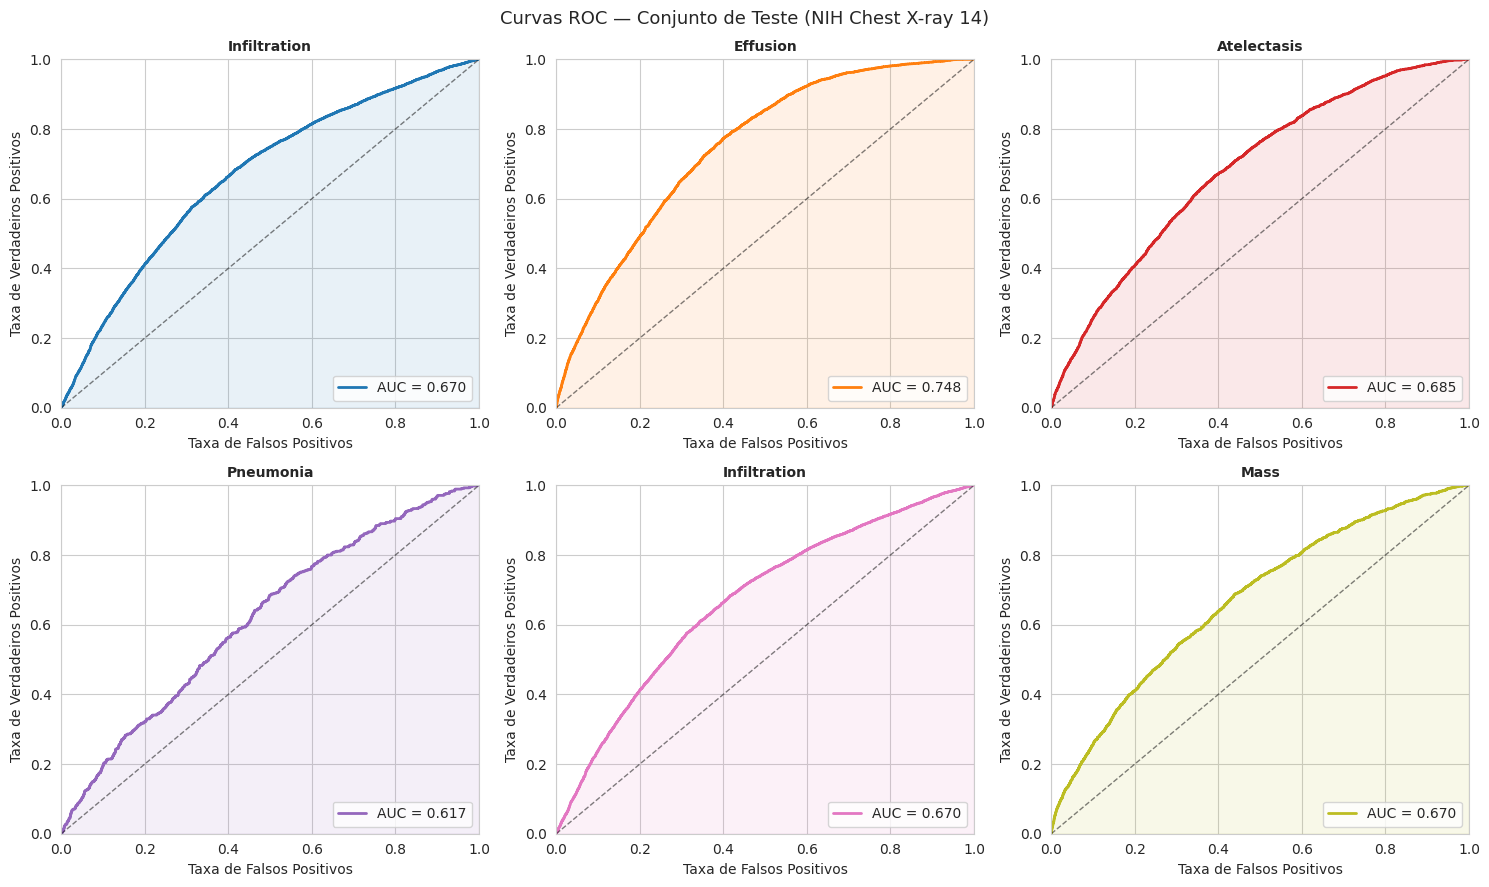

In [24]:
# ── Curvas ROC por Condição ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
# Selecionar as 6 condições com mais amostras para visualização clara
top6 = auc_df.nlargest(3, 'Positivos no Teste').index.tolist() + \
       auc_df.nsmallest(3, 'AUC-ROC').index.tolist()
top6_conds = auc_df.loc[top6[:6], 'Condição'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors_roc = plt.cm.tab10(np.linspace(0, 0.8, 6))

for ax, cond, color in zip(axes.flat, top6_conds, colors_roc):
    idx  = CONDITIONS.index(cond)
    fpr, tpr, _ = roc_curve(y_true[:, idx], y_pred[:, idx])
    auc_val = auc_scores[cond]
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_val:.3f}')
    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(cond, fontsize=10, fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos')
    ax.set_ylabel('Taxa de Verdadeiros Positivos')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Curvas ROC — Conjunto de Teste (NIH Chest X-ray 14)', fontsize=13)
plt.tight_layout()
plt.savefig('curvas_roc.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Métricas por Classe com Threshold = 0.5 ───────────────────────────────
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

THRESHOLD = 0.5
y_pred_bin = (y_pred >= THRESHOLD).astype(int)

metrics_df = pd.DataFrame({
    'Condição': CONDITIONS,
    'AUC-ROC':   [auc_scores.get(c, np.nan) for c in CONDITIONS],
    'Precisão':  precision_score(y_true, y_pred_bin, average=None, zero_division=0),
    'Recall':    recall_score(y_true, y_pred_bin, average=None, zero_division=0),
    'F1-Score':  f1_score(y_true, y_pred_bin, average=None, zero_division=0),
    'Positivos': y_true.sum(axis=0).astype(int)
})

# Médias gerais
macro_row = pd.DataFrame([{
    'Condição': '── MÉDIA MACRO ──',
    'AUC-ROC':  metrics_df['AUC-ROC'].mean(),
    'Precisão': metrics_df['Precisão'].mean(),
    'Recall':   metrics_df['Recall'].mean(),
    'F1-Score': metrics_df['F1-Score'].mean(),
    'Positivos': metrics_df['Positivos'].sum()
}])
metrics_display = pd.concat([metrics_df, macro_row], ignore_index=True)

# Formatar
for col in ['AUC-ROC', 'Precisão', 'Recall', 'F1-Score']:
    metrics_display[col] = metrics_display[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')

print('Métricas no Conjunto de Teste (threshold = 0.5)')
print('=' * 75)
print(metrics_display.to_string(index=False))

Métricas no Conjunto de Teste (threshold = 0.5)
          Condição AUC-ROC Precisão Recall F1-Score  Positivos
       Atelectasis  0.6853   0.1778 0.7954   0.2907       3279
      Cardiomegaly  0.7542   0.0776 0.7297   0.1402       1069
     Consolidation  0.6766   0.0987 0.8656   0.1772       1815
             Edema  0.7863   0.0608 0.9286   0.1142        925
          Effusion  0.7479   0.2691 0.8772   0.4118       4658
         Emphysema  0.7757   0.0883 0.7585   0.1581       1093
          Fibrosis  0.7694   0.0452 0.5517   0.0836        435
            Hernia  0.8926   0.0132 0.8256   0.0260         86
      Infiltration  0.6697   0.2918 0.8372   0.4327       6112
              Mass  0.6701   0.1098 0.5767   0.1845       1748
            Nodule  0.6787   0.1166 0.4763   0.1873       1623
Pleural_Thickening  0.6982   0.0798 0.6430   0.1419       1143
         Pneumonia  0.6174   0.0273 0.7766   0.0528        555
      Pneumothorax  0.7810   0.1962 0.8041   0.3154       2665
 ── MÉD

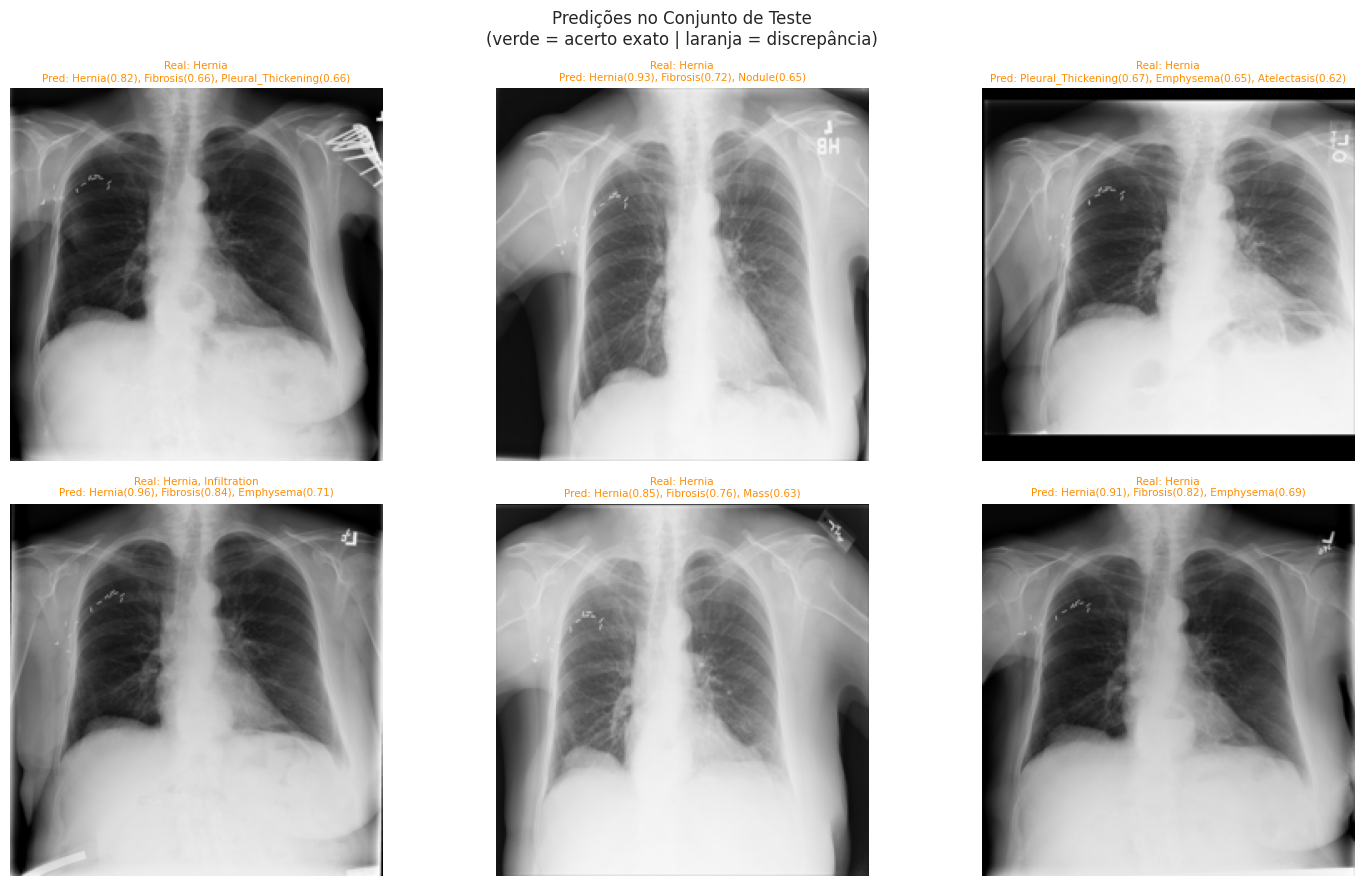

In [26]:
# ── Visualização de Predições no Conjunto de Teste ────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
# Selecionar amostras com pelo menos 1 condição predita acima do threshold
test_idx = df_test.reset_index(drop=True)
has_pred  = (y_pred >= THRESHOLD).any(axis=1)
sample_idx = np.where(has_pred)[0][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, idx in zip(axes.flat, sample_idx):
    img = Image.open(test_idx.loc[idx, 'filepath']).convert('RGB').resize((224, 224))
    ax.imshow(img, cmap='bone')

    true_labels = [CONDITIONS[j] for j in range(len(CONDITIONS)) if y_true[idx, j] == 1]
    pred_labels = [(CONDITIONS[j], y_pred[idx, j]) for j in range(len(CONDITIONS))
                   if y_pred[idx, j] >= THRESHOLD]
    pred_labels.sort(key=lambda x: -x[1])

    title_true = 'Real: ' + (', '.join(true_labels) if true_labels else 'No Finding')
    title_pred = 'Pred: ' + ', '.join([f'{n}({p:.2f})' for n, p in pred_labels[:3]])

    match = set(true_labels) == set([n for n, _ in pred_labels])
    ax.set_title(f'{title_true}\n{title_pred}', fontsize=7.5,
                 color='green' if match else 'darkorange')
    ax.axis('off')

plt.suptitle('Predições no Conjunto de Teste\n(verde = acerto exato | laranja = discrepância)',
             fontsize=12)
plt.tight_layout()
plt.savefig('predicoes_teste.png', bbox_inches='tight')
plt.show()

---
## Conclusão

### Resumo dos Resultados

| Aspecto | Detalhe |
|---------|----------|
| **Dataset** | NIH Chest X-ray 14 — subconjunto de ~27.000 imagens (de 112.120) |
| **Problema** | Classificação Multi-Label — 14 condições patológicas |
| **Arquitetura** | DenseNet121 pré-treinada (ImageNet) + cabeçalho customizado |
| **Transfer Learning** | Fase 1: cabeçalho (LR = 1e-3) → Fase 2: fine-tuning últimas 30 camadas (LR = 1e-5) |
| **Função de Perda** | Weighted Binary Cross-Entropy (compensação de desbalanceamento) |
| **Métrica Principal** | AUC-ROC por classe + Mean AUC |

### Aprendizados e Desafios

- **Desbalanceamento extremo**: Hernia (< 0,2%) vs Infiltration (~18%) → fundamental o uso de pesos por classe
- **Multi-label vs Multi-class**: exige sigmoid (não softmax) e métricas por classe (não acurácia global)
- **Transfer Learning** reduziu significativamente o tempo de treino e melhorou a generalização, especialmente em classes raras
- O **CheXNet** (artigo de referência) atingiu AUC médio de 0,841 com o dataset completo; nosso subconjunto é uma demonstração pedagógica do mesmo pipeline

### Conexão com o Sistema de Produção

O modelo treinado neste notebook usa a **mesma arquitetura, pré-processamento e função de perda** do modelo `2409_2004i.h5` que opera em produção no sistema **medc-back**, classificando 19 condições em raio-X de tórax para auxiliar diagnósticos médicos via API REST.

In [27]:
# Salvar modelo e figuras localmente
from pathlib import Path
import shutil

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

SAVE_PATH = OUTPUT_DIR / 'medc_cnn_chestxray.keras'
model.save(SAVE_PATH)
print(f'Modelo salvo em: {SAVE_PATH.resolve()}')

for fig_file in [
    'distribuicao_classes.png', 'amostras_treino.png',
    'arquitetura_modelo.png', 'curvas_treinamento.png',
    'auc_por_classe.png', 'curvas_roc.png', 'predicoes_teste.png'
]:
    source = Path(fig_file)
    if source.exists():
        shutil.copy2(source, OUTPUT_DIR / source.name)
        print(f'Figura salva: {OUTPUT_DIR / source.name}')


Modelo salvo em: /home/leozin/unifor/ciencia-dados/cnn-project/outputs/medc_cnn_chestxray.keras
Figura salva: outputs/distribuicao_classes.png
Figura salva: outputs/amostras_treino.png
Figura salva: outputs/arquitetura_modelo.png
Figura salva: outputs/curvas_treinamento.png
Figura salva: outputs/auc_por_classe.png
Figura salva: outputs/curvas_roc.png
Figura salva: outputs/predicoes_teste.png
